In [3]:
import json
import re
import matplotlib.pyplot as plt
from textblob import *

In [4]:
import pandas as pd
import numpy as np

In [5]:
import nltk
from sklearn import decomposition
from sklearn.feature_extraction.text import TfidfVectorizer
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /Users/pro/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/pro/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Summary

In [6]:
raw = json.load(open('piazza.json','r'))

In [7]:
#Number of active users in each forum
def activeUser(postlist):
    user = []
    for post in postlist:
        try:
            user.append(post['history'][-1]['uid'])
        except:
            continue
    numUser = len(set(user))
    return numUser        

In [8]:
def summary(raw):
    course = [c['num'] + ' ' + c['term'] for c in raw]
    post = []
    user = []
    for forum in raw:
        post.append(len(forum['posts']))
        user.append(activeUser(forum['posts']))
    df = pd.DataFrame({'Course': course, 'Total Posts':post, 'Active Users': user})
    df.set_index('Course', inplace=True)
    df.loc["Total"] = df.sum()
    return df 

In [9]:
summary(raw)

,Total Posts,Active Users
Course,,
ISYE- 6501-OAN Fall 2018,1701,320
Verified MM Learners ISYE- 6501 Fall 2018,448,118
ISYE- 6501-OAN Spring 2019,2550,467
VERIFIED MM LEARNERS ISYE- 6501 Spring 2019,863,189
Total,5562,1094


## Data Preprocessing

In [10]:
# Cleaning html tags from posts
def cleanhtml(raw):
    cleanr = re.compile('<.*?>')
    cleantext = re.sub(cleanr, '', raw)
    return cleantext

In [11]:
# Cleaning pin tags from posts
def cleanpin(raw):
    cleantext = re.sub('#pin','',raw)
    return cleantext

In [12]:
# Merge posts from all courses
post_list = []
for i in range(len(raw)):
    post_list.extend(raw[i]['posts'])

In [13]:
def cleanURL(raw):
    return re.sub(r"http\S+", '', raw, flags=re.MULTILINE)

In [14]:
def clean_post(raw_content):
    cleaned = cleanURL(cleanpin(cleanhtml(raw_content.replace('\u00a0',' ').replace('\n',' '))).strip())
    return cleaned

In [15]:
posts = [clean_post(post['history'][-1]['content']) for post in post_list]

### Tokenizing and Stemming

In [16]:
stopwords = nltk.corpus.stopwords.words('english')
from nltk.stem.snowball import SnowballStemmer
stemmer = SnowballStemmer("english")

# tokenization and stemming
def tokenization_and_stemming(text):
    # exclude stop words and tokenize the post, generate a list of string 
    tokens = [word.lower() for sent in nltk.sent_tokenize(text) for word in nltk.word_tokenize(sent) if word not in stopwords]
    filtered_tokens = []
    # filter out any tokens not containing letters (e.g., numeric tokens, raw punctuation)
    for token in tokens:
        if re.search('[a-zA-Z]', token):
            filtered_tokens.append(token)       
    # stemming
    stems = [stemmer.stem(t) for t in filtered_tokens]
    return stems

In [17]:
# tokenization without stemming
def tokenization(text):
    tokens = [word.lower() for sent in nltk.sent_tokenize(text) for word in nltk.word_tokenize(sent) if word not in stopwords]
    filtered_tokens = []
    for token in tokens:
        if re.search('[a-zA-Z]', token):
            filtered_tokens.append(token)
    return filtered_tokens

In [18]:
posts_stemmed = []
posts_tokenized = []
for post in posts:
    tokenized_and_stemmed_results = tokenization_and_stemming(post)
    posts_stemmed.extend(tokenized_and_stemmed_results)
    
    tokenized_results = tokenization(post)
    posts_tokenized.extend(tokenized_results)

In [19]:
# create a mapping from stemmed words to original words for interpretation
vocab_frame_dict = {posts_stemmed[x]:posts_tokenized[x] for x in range(len(posts_stemmed))}

### Word Frequency

In [20]:
from nltk.probability import FreqDist
fdist = FreqDist(posts_stemmed)
fdist.most_common(10)

[('i', 18958),
 ('use', 3624),
 ('model', 2955),
 ('data', 2765),
 ('thank', 2692),
 ('grade', 2252),
 ('would', 2120),
 ('homework', 1944),
 ('time', 1905),
 ('question', 1756)]

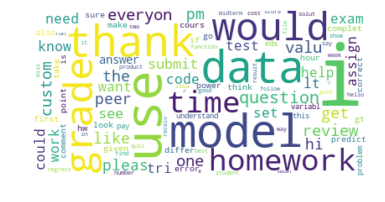

In [57]:
wordcloud = WordCloud(max_font_size=100, max_words=100, background_color="white")
wordcloud.generate_from_frequencies(fdist)
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### TF-IDF

In [21]:
# define vectorizer parameters
# TfidfVectorizer to create tf-idf matrix
# max_df : maximum document frequency for the given word
# min_df : minimum document frequency for the given word
# max_features: maximum number of words
# use_idf: if not true, we only calculate tf
# stop_words : built-in stop words
# tokenizer: how to tokenize the document
# ngram_range: (min_value, max_value), eg. (1, 3) means the result will include 1-gram, 2-gram, 3-g
tfidf_model = TfidfVectorizer(max_df=0.9, max_features=1000,
                                 min_df=0.01, stop_words='english',
                                 use_idf=True, tokenizer=tokenization_and_stemming, ngram_range=(1,1))

tfidf_matrix = tfidf_model.fit_transform(posts) #fit the vectorizer to synopses

print ("In total, there are " + str(tfidf_matrix.shape[0]) + \
      " reviews and " + str(tfidf_matrix.shape[1]) + " terms.")

/anaconda3/lib/python3.7/site-packages/sklearn/feature_extraction/text.py:300: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['afterward', 'alon', 'alreadi', 'alway', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becom', 'besid', 'cri', 'describ', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'otherwis', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'thenc', 'thereaft', 'therebi', 'therefor', 'togeth', 'twelv', 'twenti', 'whatev', 'whenc', 'whenev', 'wherea', 'whereaft', 'wherebi', 'wherev'] not in stop_words.
  'stop_words.' % sorted(inconsistent))


In total, there are 5562 reviews and 639 terms.


In [22]:
tf_selected_words = tfidf_model.get_feature_names()

In [23]:
tf_selected_words[:10]

['abl',
 'accept',
 'access',
 'accord',
 'account',
 'accur',
 'accuraci',
 'actual',
 'ad',
 'add']

### Post Similarity

In [24]:
import seaborn as sns

In [25]:
from sklearn.metrics.pairwise import cosine_similarity
cos_matrix = cosine_similarity(tfidf_matrix)
print (cos_matrix)

[[1.         0.02512228 0.02518753 ... 0.         0.         0.36095952]
 [0.02512228 1.         0.9937701  ... 0.         0.         0.04972273]
 [0.02518753 0.9937701  1.         ... 0.         0.         0.05198987]
 ...
 [0.         0.         0.         ... 1.         1.         0.        ]
 [0.         0.         0.         ... 1.         1.         0.        ]
 [0.36095952 0.04972273 0.05198987 ... 0.         0.         1.        ]]


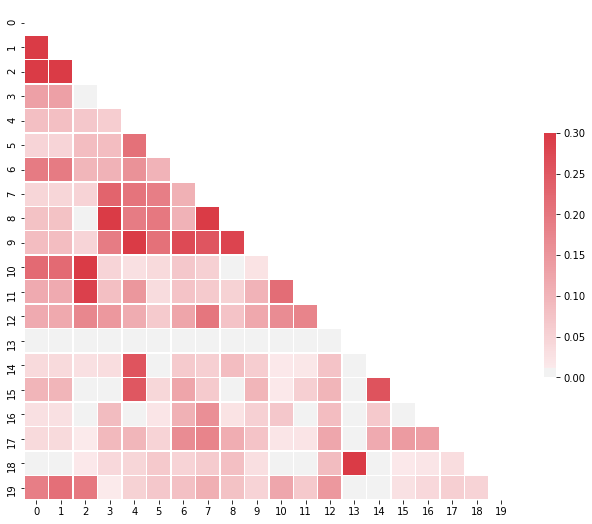

In [26]:
corr = cos_matrix[1:21, 1:21]
# Compute the correlation matrix

# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [27]:
pair = np.argwhere(np.tril(cos_matrix, -1) > 0.9)

In [201]:
def similar_posts(pair):
    similarPosts = []
    for i, j in pair:
        similarPosts.append([posts[i], posts[j]])
    return similarPosts

In [202]:
s = similar_posts(pair)
print(s[:10])

[['The grades for homework 13 are released. The average (as of now) is 60.52.If you had only two peer reviews, I completed a third (unofficial) review and took the median from there. If you only had one review, I submitted my own review and took the median (rounding up in cases with non-schema medians). If you had more than 3 peer reviews, I took the median from the highest three gradesI may have made a mistake when inputting or missed a comment saying to change your review to some other grade, or something else entirely. Please let me know ASAP if there are any issues like this, I will get them resolved and make sure you are fairly graded or treated.If you have a regrade request, please follow the guidelines presented &#64;7 and &#64;326. Regrade requests must be done within 48 hours of grade release.   Thanks again for your continued patience and let me or the other TAs know if you have any Questions!', 'The grades for the project are released. The average (as of now) is 88.53.If you

### K-Means Clustering

In [169]:
from sklearn.cluster import KMeans

# number of clusters
num_clusters = 4
km = KMeans(n_clusters=num_clusters)
km.fit(tfidf_matrix)
clusters = km.labels_.tolist()

In [170]:
frame = pd.DataFrame({'Post': posts, 'cluster': clusters}, index = [clusters])

In [137]:
c = frame['cluster'].value_counts().to_frame()

In [147]:
c.reset_index(level=0, inplace=True)

In [156]:
c = c.rename(columns={"index": "cluster", "cluster": "count"})

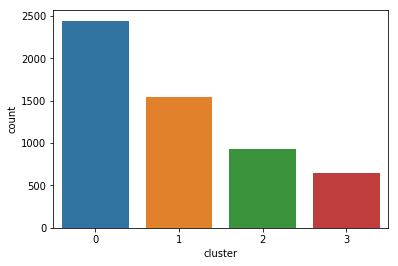

In [158]:
ax = sns.barplot(x = 'cluster', y='count', data = c)

In [171]:
print ("<Post clustering result by K-means>")

# km.cluster_centers_ denotes the importances of each items in centroid.
# sort it in decreasing-order to get the top k items.
order_centroids = km.cluster_centers_.argsort()[:, ::-1] 

Cluster_keywords_summary = {}
for i in range(num_clusters):
    print ("Cluster " + str(i) + " words:", end='')
    Cluster_keywords_summary[i] = []
    for ind in order_centroids[i, :10]:
        Cluster_keywords_summary[i].append(vocab_frame_dict[tf_selected_words[ind]])
        print (vocab_frame_dict[tf_selected_words[ind]] + ",", end='')
    print ()
    cluster_posts = frame.iloc[[i]]['Post'].values.tolist()
    print (", ".join(cluster_posts))
    print ()
    


<Post clustering result by K-means>
Cluster 0 words:exam,proctortrack,quiz,midterm,proctored,edx,thanks,onboarding,finally,hi,
Hi everyone,  We ask that if you have any questions about a particular question, you do it here. As a part of a discussion below this note. This way, it saves people time from having to search multiple Piazza posts and also saves the instructors from a flood of private and public questions.

Cluster 1 words:thanks,questions,homework,hi,course,using,file,link,time,submitting,
The grades for the project are released. The average (as of now) is 88.53.If you had only two peer reviews, I completed a third (unofficial) review and took the median from there. If you only had one review, I submitted my own review and took the median (rounding up in cases with non-schema medians). If you had more than 3 peer reviews, I took the median from the highest three gradesI may have made a mistake when inputting or missed a comment saying to change your review to some other grade

In [192]:
def KCluster_wordCould():
    cols = [color for name, color in mcolors.TABLEAU_COLORS.items()]  
    cloud = WordCloud(stopwords= STOPWORDS,
                      background_color='white',
                      width=2500,
                      height=1800,
                      max_font_size = 200,
                      max_words=10,
                      colormap='tab10',
                      color_func=lambda *args, **kwargs: cols[i],
                      prefer_horizontal=1.0)



    fig, axes = plt.subplots(2, 2, figsize=(10,10), sharex=True, sharey=True)

    for i, ax in enumerate(axes.flatten()):
        fig.add_subplot(ax)
        cloud.generate_from_text(' '.join(Cluster_keywords_summary[i]))
        plt.gca().imshow(cloud)
        plt.gca().set_title('Cluster ' + str(i),fontdict=dict(size=16))
        plt.gca().axis('off')


    plt.subplots_adjust(wspace=0, hspace=0)
    plt.axis('off')
    plt.margins(x=0, y=0)
    plt.tight_layout()
    plt.show()

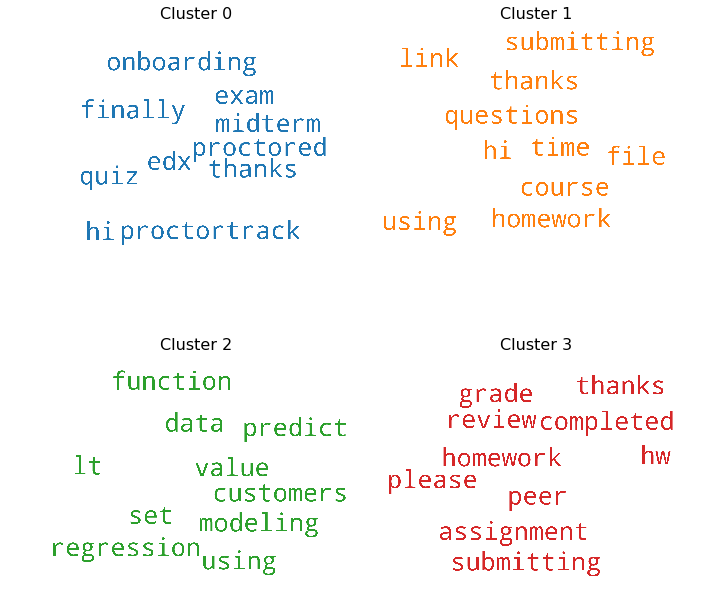

In [193]:
KCluster_wordCould()

In [33]:
# use pca to reduce dimensions to 2d for visibility, just want to see if there 2d can give us some insights
# this is not an appropriate method, just a guess.
pca = decomposition.PCA(n_components=2)
tfidf_matrix_np=tfidf_matrix.toarray()
pca.fit(tfidf_matrix_np)
X = pca.transform(tfidf_matrix_np)

xs, ys = X[:, 0], X[:, 1]

#set up colors per clusters using a dict
cluster_colors = {0: '#1b9e77', 1: '#d95f02', 2: '#7570b3', 3: '#e7298a'}
#set up cluster names using a dict
cluster_names = {}
for i in range(num_clusters):
    cluster_names[i] = ", ".join(Cluster_keywords_summary[i])

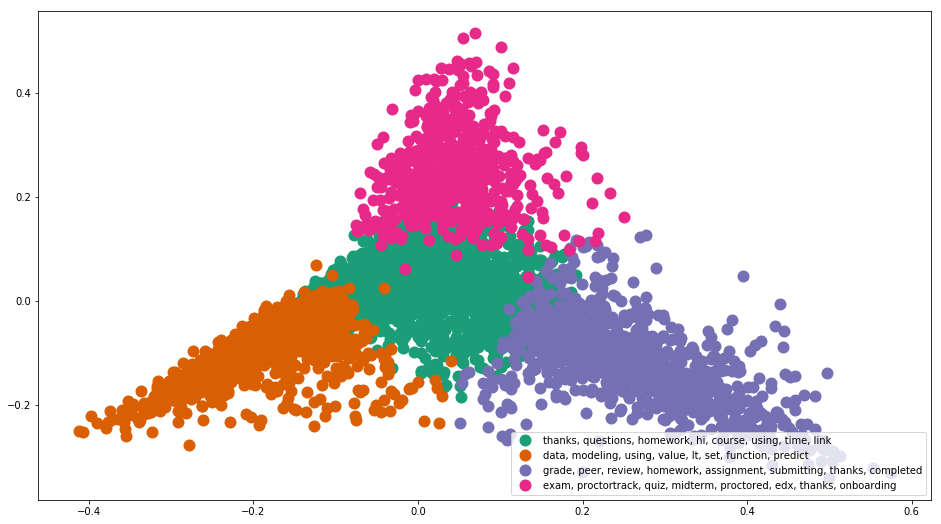

In [34]:
%matplotlib inline 
#create data frame with PCA cluster results
df = pd.DataFrame(dict(x=xs, y=ys, label=clusters)) 
groups = df.groupby(clusters)

# set up plot
fig, ax = plt.subplots(figsize=(16, 9))
#Set color for each cluster/group
for name, group in groups:
    ax.plot(group.x, group.y, marker='o', linestyle='', ms=12, 
            label=cluster_names[name], color=cluster_colors[name], 
            mec='none')

ax.legend(numpoints=1,loc=4)  #show legend with only 1 point, position is right bottom.

plt.show() #show the plot

### LDA

In [35]:
from sklearn.decomposition import LatentDirichletAllocation
lda = LatentDirichletAllocation(n_components=4, learning_method = 'online')

In [37]:
from sklearn.feature_extraction.text import CountVectorizer
# LDA requires integer values
tfidf_model_lda = CountVectorizer(max_df=0.9, max_features=1000,
                                 min_df=0.01, stop_words='english',
                                 tokenizer=tokenization_and_stemming, ngram_range=(1,3))

tfidf_matrix_lda = tfidf_model_lda.fit_transform(posts) 

print ("In total, there are " + str(tfidf_matrix_lda.shape[0]) + \
      " reviews and " + str(tfidf_matrix_lda.shape[1]) + " terms.")

/anaconda3/lib/python3.7/site-packages/sklearn/feature_extraction/text.py:300: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['afterward', 'alon', 'alreadi', 'alway', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becom', 'besid', 'cri', 'describ', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'otherwis', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'thenc', 'thereaft', 'therebi', 'therefor', 'togeth', 'twelv', 'twenti', 'whatev', 'whenc', 'whenev', 'wherea', 'whereaft', 'wherebi', 'wherev'] not in stop_words.
  'stop_words.' % sorted(inconsistent))


In total, there are 5562 reviews and 713 terms.


In [38]:
lda_output = lda.fit_transform(tfidf_matrix_lda)
print(lda_output.shape)
print(lda_output)

(5562, 4)
[[0.01158215 0.96463391 0.01171526 0.01206868]
 [0.00359004 0.00362807 0.00356477 0.98921711]
 [0.00353903 0.00355699 0.00351396 0.98939001]
 ...
 [0.84999198 0.05000701 0.05000074 0.05000027]
 [0.84999198 0.05000701 0.05000074 0.05000027]
 [0.0021692  0.99340949 0.00219087 0.00223044]]


In [39]:
# column names
topic_names = ["Topic" + str(i) for i in range(lda.n_components)]

# index names
post_names = ["Post" + str(i) for i in range(len(posts))]

df_post_topic = pd.DataFrame(np.round(lda_output, 2), columns=topic_names, index=post_names)

# get dominant topic for each post
topic = np.argmax(df_post_topic.values, axis=1)
df_post_topic['topic'] = topic

df_post_topic.head(10)

,Topic0,Topic1,Topic2,Topic3,topic
Post0,0.01,0.96,0.01,0.01,1
Post1,0.00,0.00,0.00,0.99,3
Post2,0.00,0.00,0.00,0.99,3
Post3,0.01,0.25,0.01,0.74,3
Post4,0.01,0.17,0.01,0.81,3
Post5,0.00,0.45,0.46,0.09,2
Post6,0.30,0.14,0.56,0.00,2
Post7,0.01,0.43,0.01,0.55,3
Post8,0.01,0.98,0.01,0.01,1
Post9,0.20,0.44,0.01,0.35,1


In [69]:
a = [[1,3],[1,4]]
b = enumerate(a)
for i, j in b:
    print(i,j)

0 [1, 3]
1 [1, 4]


In [40]:
df_post_topic['topic'].value_counts().to_frame()

,topic
0,1987
1,1603
3,1215
2,757


In [98]:
lda.components_

array([[ 64.05714643,  20.63284714,   0.26214974, ...,  34.90298322,
          0.48263579,   6.86295347],
       [236.06317795,  46.88683558, 211.85221244, ..., 103.53955029,
         34.42908852,  34.59694688],
       [183.47779795,   5.80043554,  43.90363428, ...,   0.27074522,
          1.74704218,   0.27670746],
       [ 50.52496646,  47.94440022,   0.26865436, ...,   0.25418378,
         34.47837881, 207.47576059]])

In [41]:
# print top n keywords for each topic
def print_topic_words(tfidf_model, lda_model, n_words):
    words = np.array(tfidf_model.get_feature_names())
    topic_words = []
    # for each topic, we have words weight
    for topic_words_weights in lda_model.components_:
        top_words = topic_words_weights.argsort()[::-1][:n_words]
        topic_words.append(words.take(top_words))
    return topic_words

topic_keywords = print_topic_words(tfidf_model=tfidf_model_lda, lda_model=lda, n_words=15)        

df_topic_words = pd.DataFrame(topic_keywords)
df_topic_words.columns = ['Word '+str(i) for i in range(df_topic_words.shape[1])]
df_topic_words.index = ['Topic '+str(i) for i in range(df_topic_words.shape[0])]
df_topic_words

,Word 0,Word 1,Word 2,Word 3,Word 4,Word 5,Word 6,Word 7,Word 8,Word 9,Word 10,Word 11,Word 12,Word 13,Word 14
Topic 0,model,data,use,valu,lt,set,predict,gt,error,test,variabl,function,differ,regress,c
Topic 1,everyon,pm,thank,homework,question,cours,hour,time,hw,work,code,file,offic,post,offic hour
Topic 2,custom,exam,time,power,use,pay,cost,quiz,product,given,proctortrack,month,compani,payment,determin
Topic 3,grade,review,peer,pleas,homework,thank,peer review,submit,comment,complet,hi,assign,receiv,know,score


In [47]:
print(lda.components_)
# topic-word matrix
df_topic_words = pd.DataFrame(lda.components_)

# column and index
df_topic_words.columns = tfidf_model_lda.get_feature_names()
df_topic_words.index = topic_names

df_topic_words

[[ 64.05714643  20.63284714   0.26214974 ...  34.90298322   0.48263579
    6.86295347]
 [236.06317795  46.88683558 211.85221244 ... 103.53955029  34.42908852
   34.59694688]
 [183.47779795   5.80043554  43.90363428 ...   0.27074522   1.74704218
    0.27670746]
 [ 50.52496646  47.94440022   0.26865436 ...   0.25418378  34.47837881
  207.47576059]]


,abl,accept,access,accord,account,accur,accuraci,actual,ad,add,...,work,worth,write,written,wrong,x,year,yes,yesterday,zero
Topic0,64.057146,20.632847,0.262150,25.240054,0.783889,50.104371,447.322838,140.962935,113.293872,116.625120,...,199.516444,0.309625,29.929867,11.795776,179.668209,575.103176,269.568671,34.902983,0.482636,6.862953
Topic1,236.063178,46.886836,211.852212,6.297713,0.261663,15.845034,0.253581,46.999804,28.633273,69.525149,...,611.946688,54.921515,102.791420,53.486119,22.129387,0.255384,18.528132,103.539550,34.429089,34.596947
Topic2,183.477798,5.800436,43.903634,9.009264,268.459698,0.299663,0.250364,57.066496,9.255866,0.287504,...,169.259700,35.696027,10.990512,0.301476,12.247153,0.255126,16.428278,0.270745,1.747042,0.276707
Topic3,50.524966,47.944400,0.268654,21.341074,0.262271,11.426658,0.340932,77.386312,32.058455,15.561949,...,137.589571,0.724813,8.809727,0.263337,112.507357,0.278466,1.576758,0.254184,34.478379,207.475761


In [199]:
from matplotlib import pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import matplotlib.colors as mcolors

def plot_topic_keywords(tfidf_model, lda_model, n_words): 
    cols = [color for name, color in mcolors.TABLEAU_COLORS.items()]  
    cloud = WordCloud(stopwords= STOPWORDS,
                      background_color='white',
                      width=2500,
                      height=1800,
                      max_words=10,
                      colormap='tab10',
                      color_func=lambda *args, **kwargs: cols[i],
                      prefer_horizontal=1.0)

    words = np.array(tfidf_model.get_feature_names())
    out = []
    for topic_words_weights in lda_model.components_:
        top_words = topic_words_weights.argsort()[::-1][:n_words]
        word = words.take(top_words)
        out.append(dict(zip(word,topic_words_weights)))

    fig, axes = plt.subplots(2, 2, figsize=(10,10), sharex=True, sharey=True)

    for i, ax in enumerate(axes.flatten()):
        fig.add_subplot(ax)
        cloud.generate_from_frequencies(out[i], max_font_size=500)
        plt.gca().imshow(cloud)
        plt.gca().set_title('Topic ' + str(i), fontdict=dict(size=16))
        plt.gca().axis('off')


    plt.subplots_adjust(wspace=0, hspace=0)
    plt.axis('off')
    plt.margins(x=0, y=0)
    plt.tight_layout()
    plt.show()

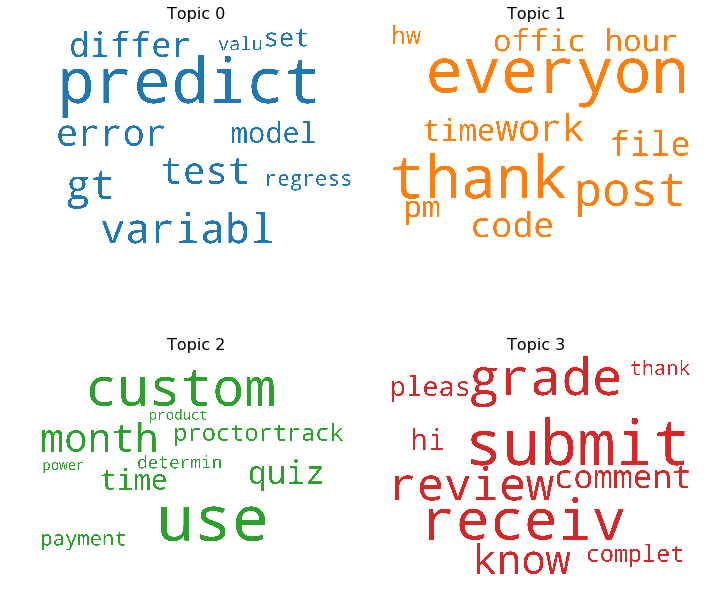

In [200]:
plot_topic_keywords(tfidf_model= tfidf_model_lda, lda_model=lda, n_words=15)

### Negative Posts

In [36]:
def find_neg_post(posts, limit):
    neg_post = []
    for post in posts:
        blob = TextBlob(post)
        if blob.sentiment.polarity < limit:
            neg_post.append(post)
    n = len(neg_post)
    ratio = n/len(posts)
    print(n, ratio)
    return neg_post


In [37]:
find_neg_post(posts, -0.3)

90 0.016181229773462782


['I apologized for not completing the peer grading on time. I still hope that you can excuse me this time.  My mom was very sick, and I stayed with her through the week end.  I totally forgot; even if I remembered, I couldn’t even get it done because there is no internet at my mom’s house.  Thank you for your understanding.  I promise it won’t happen again.  Thank you!!!',
 'I just tried to launch Proctortrack (a lot of issues, but helpful person from Proctortrack talked me  through), THEN something like RPNow started to launch. What is the difference? Also it seemed that RPNow did not work with Proctortrack. Can somebody please explain? This is very confusing.',
 'Where in canvas should we look for the score or grade? I mean which tab/link?',
 'I suspect a plagiarism in one of the project paper I reviewed: Maybe I am wrong but I just want to bring it to your attention:  &#34; Mobile Diabetes factor  management&#34;',
 'I have been sick and was wondering if I could get an extension on 